## ¿Qué es Behavioral Testing?
Forma de testear software que se enfoca en verificar que el sistema cumpla con el comportamiento esperado desde la perspectiva del usuario final.
* Se basa en **escenarios reales de uso** escritos en lenguaje natural estructurado.
* Parte del enfoque **Behavior-Driven Development (BDD)**: primero se escriben los escenarios de comportamiento, luego se escribe código.

    🔁 En lugar de preguntar: 
    >"¿Está bien este bloque de código?"
    
    ✅ Se pregunta: 
    >"¿**Hace el sistema lo que el usuario espera**?"

### La filosofía BDD
* BDD es una forma de pensar el desarrollo de software.
* Nace como una evolución del TDD (Test-Driven Development) para acercar la conversación entre devs, QA y negocio.
* Se basa en ejemplos concretos de comportamiento del sistema.
* Primero se escribe el comportamiento esperado (escenario), después se implementa el código que lo satisface.
* Los tests se convierten en una fuente de verdad compartida.


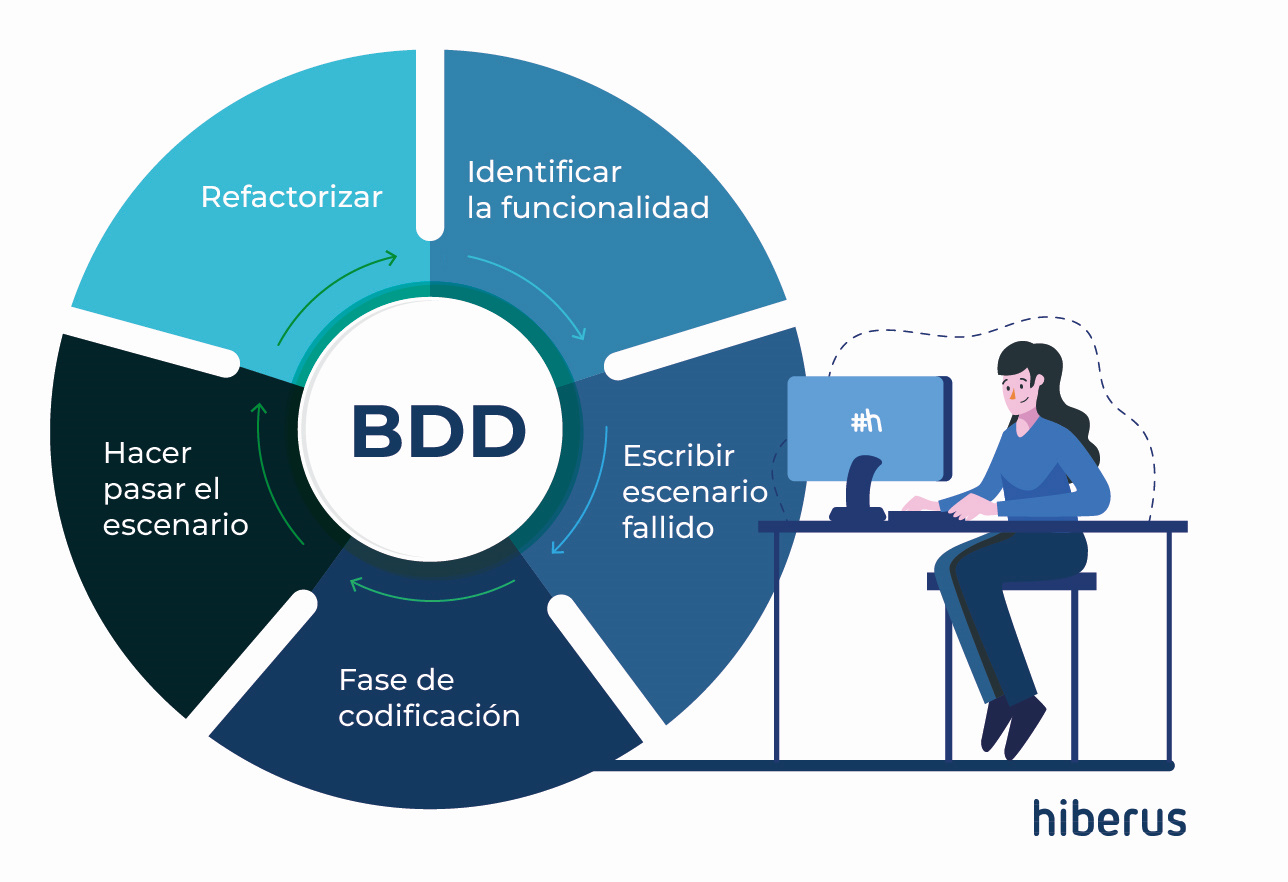

⚠️ No hace falta implementar BDD completo para hacer Behavioral Testing.

**Ejemplos de casos de uso**

| **Resultados esperados**                                    | **Flujos de interacción**                                   | **Reglas del negocio**                                       |
|-------------------------------------------------------------|-------------------------------------------------------------|---------------------------------------------------------------|
| Si ingreso credenciales válidas, ¿puedo entrar?             | ¿El usuario puede completar el checkout en 3 pasos?         | ¿Los menores de 18 pueden registrarse?                        |
| Si el carrito está vacío, ¿me bloquea el pago?              | ¿Qué pasa si el usuario abandona a mitad del flujo?         | ¿El sistema calcula impuestos correctamente según el país?    |
|             |                                                             |                                                               |

**Nuevamente, nos enfocamos en qué debería pasar desde el punto de vista del usuario y no cómo.**

### Como se ve en la práctica


**Ejemplo en Gherkin**
    
    Feature: Autenticación de usuarios
        Scenario: Inicio de sesión exitoso
            Given el usuario se encuentra en la página de login
            When ingresa credenciales válidas
            Then accede al sistema y es redirigido al panel principal


### Cucumber 

🧩 Herramienta para aplicar BDD en proyectos de software

* Cucumber permite automatizar escenarios de comportamiento escritos en lenguaje natural (o Gherkin).

* Facilita la colaboración entre desarrolladores, testers y negocio, ya que todos pueden entender los tests.

* Traduce escenarios a código ejecutable que valide si el sistema cumple ese comportamiento.

* Sirve como documentación!

### Gherkin (Tomi)

### Behave (Fran)

**Behave es una libreria de Python que permite aplicar el enfoque de BDD**

- Se instala con pip install behave

¿Cómo funciona?


- Behave opera en directorios que contienen:

1. Archivos .feature, que contienen escenarios escritos en lenguaje Gherkin. Los suele escribir el Product Owner y son el punto de entrada de los tests de Cucumber.
2. Un directorio _steps_ donde están definidos los pasos (e.g Given, Then, When) en archivos .py



Ejemplo:


Estructura:

features/login.feature

features/steps/autenticacion.py





In [ ]:
login.feature:

#language: es



Feature: Autenticacion de usuarios
    Scenario: Inicio de sesion exitoso
        Given el usuario se encuentra en la página de login
        When ingresa credenciales válidas
        Then accede al sistema y es redirigido al panel principal


In [ ]:
autenticacion.py:

from behave import given, when, then
from selenium import webdriver
from selenium.webdriver.common.by import By
import time

@given('el usuario se encuentra en la página de login')
def step_impl(context):
    context.driver = webdriver.Chrome()  
    context.driver.get("http://localhost:8000/login")  
    assert "Login" in context.driver.title

@when('ingresa credenciales válidas')
def step_impl(context):
    user_input = context.driver.find_element(By.NAME, "username")
    password_input = context.driver.find_element(By.NAME, "password")
    login_button = context.driver.find_element(By.ID, "login-btn")

    user_input.send_keys("usuario_valido")
    password_input.send_keys("contraseña_segura")
    login_button.click()

@then('accede al sistema y es redirigido al panel principal')
def step_impl(context):
    time.sleep(2)  # espera a que cargue la página
    assert "Panel Principal" in context.driver.page_source
    context.driver.quit()




Para ejecutar, podemos correr _behave steps/autenticacion.py_

In [ ]:
Resultado de ejemplo exitoso:

1 feature passed, 0 failed, 0 skipped
1 scenario passed, 0 failed, 0 skipped
3 steps passed, 0 failed, 0 skipped, 0 undefined
Took 5.822s


Resultado de ejemplo con errores:

Feature: Autenticación de usuarios # features/autenticacion.feature:2

  Scenario: Inicio de sesión exitoso # features/autenticacion.feature:4
    Given el usuario se encuentra en la página de login
      Traceback (most recent call last):
        ...
      AssertionError: 
      Assertion failed in step 'el usuario se encuentra en la página de login'
    When ingresa credenciales válidas
    Then accede al sistema y es redirigido al panel principal

1 feature failed, 0 passed
1 scenario failed, 0 passed
1 step failed, 2 skipped, 0 undefined
Took 3.209s


Los *Given*, *When* y *Then* forman los *steps* o pasos que va a tomar behave al testear.

**Given:**  "Dado que" ponemos el sistema en un estado conocido antes de que el usuario (o sistema externo) comience a interactuar con el sistema (en los pasos Cuando). 

Se debe evitar hablar de la interacción del usuario en los Given.

**When:**  Cuando realizamos acciones clave que el usuario (o sistema externo) ejecuta. Esta es la interacción con el sistema que podría causar un cambio de estado.


**Then**: Entonces observamos resultados.

Se pueden incluir **And** o **But** como un paso. En este caso, behave renombra los pasos para que tomen el nombre del paso anterior, por ejemplo:

Scenario: Oponente más fuerte
  *Given* que el ninja es cinturón negro
   *When* atacado por Chunk Norris
   *Then* el ninja debería escapar
    *And* caerse de un acantilado


En este caso _behave_ va a buscar por una definición de step "Then caerse de un acantilado"

**Implementación de Steps**


Los pasos utilizados en los escenarios se implementan en archivos python en el directorio «steps». Pueden tener cualquier nombre siempre que utilicen la extensión de archivo python *.py. No hace falta decirle a behave cuáles usar, ya que los usará todos.

Los pasos se identifican usando decoradores que coinciden con el predicado del fichero de características: given, when, then y step. El decorador acepta un string que contiene el resto de la frase usada en el paso del escenario al que pertenece.


Scenario: Search for an account
   Given I search for a valid account
    Then I will see the account details


@given('I search for a valid account')
def step_impl(context):
    context.browser.get('http://localhost:8000/index')
    form = get_element(context.browser, tag='form')
    get_element(form, name="msisdn").send_keys('61415551234')
    form.submit()

@then('I will see the account details')
def step_impl(context):
    elements = find_elements(context.browser, id='no-account')
    eq_(elements, [], 'account not found')
    h = get_element(context.browser, id='account-head')
    ok_(h.text.startswith("Account 61415551234"),
        'Heading %r has wrong text' % h.text)


Cuando se corre behave, escanea los archivos step y crea un registro interno de steps, donde el identificador de cada step es el string (e.g "I will see the account details").
Ya que el identificador es el string dentro del decorador, no hace falta que las funciones tenga un nombre único, por lo que se pueden definir a todas como "step_impl".



**Scenario Outlines:**

A veces un escenario debe ejecutarse con un número de variables que dan un conjunto de estados conocidos, acciones a tomar y resultados esperados, todos usando las mismas acciones básicas. Para eso, puede usar un esquema de escenario:

Scenario Outline: Licuadora
   Given pongo <cosa> en la licuadora,
    When prendo la licuadora
    Then deberia transformarse en <otra cosa>

    
Examples: Comidas

| cosa       | otra cosa     |
|------------|---------------|
| hielo      | hielo picado  |
| café       | café molido   |
| tomate     | salsa         |
| manzana    | compota       |


Examples: Materiales

| cosa           | otra cosa                  |
|----------------|----------------------------|
| papel          | confeti                    |
| lápiz          | astillas                   |
| smartphone     | lágrimas y arrepentimiento |
| plástico       | microplásticos             |
| disco compacto | brillo                      |


behave va a correr el escenario por cada linea (no encabezada) en las tablas


**Step Data** 

A veces es útil asociar una tabla de datos con un step


Scenario: algun escenario
  Given un conjunto de usuarios específicos
     | nombre     | departmento  |
     | Barry     | Beer Cans   |
     | Pudey     | Silly Walks |
     | Two-Lumps | Silly Walks |

 When contamos la cantidad de usuarios en cada departamento
 Then vamos a encontrar dos usuarios en "Silly Walks"
  But vamos a encontrar un usuario en "Beer Cans"



In [ ]:
@given('un conjunto de usuarios específicos')
def step_impl(context):
    for row in context.table:
        model.add_user(name=row['name'], department=row['department'])

In [ ]:
# steps/correo.py


from behave import given, when, then

@given('que redacto un correo con el siguiente contenido:')
def step_impl(context):
    context.correo_redactado = context.text.strip()

@when('envío el correo')
def step_impl(context):
    # En este ejemplo simple, simplemente "guardamos" el contenido enviado
    context.correo_enviado = context.correo_redactado

@then('el contenido del correo enviado debería ser:')
def step_impl(context):
    esperado = context.text.strip()
    assert context.correo_enviado == esperado, f"\nEsperado:\n{esperado}\n\nObtenido:\n{context.correo_enviado}"


### Pytest-bdd (si queda tiempo)


Pytest-bdd es un framework que permite automatizar el testeo de requerimientos 

Se instala con 

pip install pytest-bdd


Al igual que behave, usa archivos .feature:

# content of publish_article.feature

Feature: Blog
    A site where you can publish your articles.

    Scenario: Publishing the article
        Given I'm an author user
        And I have an article

        When I go to the article page
        And I press the publish button

        Then I should not see the error message
        And the article should be published




# content of test_publish_article.py

from pytest_bdd import scenario, given, when, then

@scenario('publish_article.feature', 'Publishing the article')
def test_publish():
    pass


@given("I'm an author user")
def author_user(auth, author):
    auth['user'] = author.user


@given("I have an article", target_fixture="article")
def article(author):
    return create_test_article(author=author)


@when("I go to the article page")
def go_to_article(article, browser):
    browser.visit(urljoin(browser.url, '/manage/articles/{0}/'.format(article.id)))


@when("I press the publish button")
def publish_article(browser):
    browser.find_by_css('button[name=publish]').first.click()


@then("I should not see the error message")
def no_error_message(browser):
    with pytest.raises(ElementDoesNotExist):
        browser.find_by_css('.message.error').first


@then("the article should be published")
def article_is_published(article):
    article.refresh()  # Refresh the object in the SQLAlchemy session
    assert article.is_published



Las funciones decoradas con @scenario funcionan como un test normal, y son ejecutadas despues de todos los pasos.

from pytest_bdd import scenario, given, when, then

@scenario('publish_article.feature', 'Publishing the article')
def test_publish(browser):
    assert article.title in browser.html